# Data Management — BBO Capstone

Load weekly results from the portal, update function data, and inspect statistics.
Run this after you receive results for a given week, then use **weekly_workflow.ipynb** for the next week.

## 1. Setup

In [1]:
import sys
from pathlib import Path
root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))

from src.data import (
    FunctionData,
    DATA_DIR,
    load_results,
    load_latest_results,
    initialize_all_weeks,
    update_all_functions_with_results,
    update_function_with_result,
)
from src.utils import display_competition_summary, plot_progress, analyze_weekly_performance

print("✓ Imports ready")

✓ Imports ready


## 2. Load functions and historical data

In [2]:
functions = {i: FunctionData(i, data_dir=DATA_DIR) for i in range(1, 9)}
num_weeks = initialize_all_weeks(functions)
print(f"✓ Loaded {len(functions)} functions with {num_weeks} weeks of history")

INITIALIZING FUNCTIONS FROM HISTORICAL DATA
Source: /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results
Loading weeks: [1, 2, 3, 4]

✓ Loaded Week 1 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_1
✓ Week 1: Updated 8 functions
✓ Loaded Week 2 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_2
✓ Week 2: Updated 8 functions
✓ Loaded Week 3 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_3
✓ Week 3: Updated 8 functions
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_4
✓ Week 4: Updated 8 functions

✓ Initialization complete: 4 weeks loaded

Function states:
  Function 1 (2D): 14 samples, best=0.000000
  Function 2 (2D): 14 samples, best=0.620709
  Function 3 (3D): 19 samples, best=-0.022206
  Function 4 (4D): 34 samples, best=0.661171
  Function 5 (4

## 3. Load new week results

After you receive results from the portal, save them into `data/results/week_N/` (create the folder if needed):
- `inputs.txt` — one list of 8 arrays (or append to existing format)
- `outputs.txt` — one list of 8 floats

Then run the cell below to load the **latest** week (or change `week_index`).

In [5]:
# Load latest week's results (or set week_index: 0=week 1, 1=week 2, -1=latest)
inputs_dict, outputs_dict, week_num = load_latest_results()
print(f"Week {week_num}: {len(inputs_dict)} functions")

✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_4
Week 4: 8 functions


## 4. Update all functions with new results

In [6]:
# Update in-memory and save to data/function_N/week_W_inputs.npy and week_W_outputs.npy
update_all_functions_with_results(functions, inputs_dict, outputs_dict, week_num, save=True)

UPDATING ALL FUNCTIONS WITH WEEK 4 RESULTS

✓ Function 1 (2D): y=0.000000, best=0.000000
    Total samples: 15

✓ Function 2 (2D): y=0.620709, best=0.620709
    Total samples: 15

✓ Function 3 (3D): y=-0.033137, best=-0.022206
    Total samples: 20

✓ Function 4 (4D): y=0.030374, best=0.661171
    Total samples: 35

✓ Function 5 (4D): y=7223.214755, best=7223.214755
    Total samples: 25

✓ Function 6 (5D): y=-0.937196, best=-0.565491
    Total samples: 25

✓ Function 7 (6D): y=1.585187, best=2.468092
    Total samples: 35

✓ Function 8 (8D): y=9.224209, best=9.931870
    Total samples: 45

✓ Updated 8 functions. New bests: 0


[{'func_id': 1,
  'n_dims': 2,
  'y': 1.1314892668581908e-47,
  'best_y': np.float64(7.710875114502849e-16),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 15},
 {'func_id': 2,
  'n_dims': 2,
  'y': 0.6207093868270447,
  'best_y': np.float64(0.6207093868270447),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 15},
 {'func_id': 3,
  'n_dims': 3,
  'y': -0.03313686818015059,
  'best_y': np.float64(-0.02220601478624556),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 20},
 {'func_id': 4,
  'n_dims': 4,
  'y': 0.030374468029574775,
  'best_y': np.float64(0.6611706964725319),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 35},
 {'func_id': 5,
  'n_dims': 4,
  'y': 7223.214754607814,
  'best_y': np.float64(7223.214754607814),
  'is_new_best': np.False_,
  'improvement': 0.0,
  'n_samples': 25},
 {'func_id': 6,
  'n_dims': 5,
  'y': -0.9371960986964031,
  'best_y': np.float64(-0.5654905754990652),
  'is_new_best': np.False

## 5. Analyze week performance (optional)

In [7]:
analysis = analyze_weekly_performance(week_num, functions)

ANALYZING WEEK 4 PERFORMANCE
✓ Loaded Week 4 from /home/robin/Personal_Development/Capstone-Project-ML-AI-Imperial-College/data/results/week_4
Func   Dims   Old Best     New Value    Change       Status         
--------------------------------------------------------------------------------
1      2      0.000000     0.000000        -0.000000 ✗ Declining    
2      2      0.620709     0.620709        +0.000000 → Stagnant     
3      3      -0.022206    -0.033137       -0.010931 ✗ Declining    
4      4      0.661171     0.030374        -0.630796 ✗ Declining    
5      4      7223.214755  7223.214755     +0.000000 → Stagnant     
6      5      -0.565491    -0.937196       -0.371706 ✗ Declining    
7      6      2.468092     1.585187        -0.882905 ✗ Declining    
8      8      9.931870     9.224209        -0.707661 ✗ Declining    


## 6. Summary and progress plots

COMPETITION SUMMARY
Total weekly submissions: 0
Best values by function:
--------------------------------------------------------------------------------
Function 1 (2D): 0.000000 (+0.000000, 15 samples)
Function 2 (2D): 0.620709 (+0.081713, 15 samples)
Function 3 (3D): -0.022206 (+0.089916, 20 samples)
Function 4 (4D): 0.661171 (+22.769458, 35 samples)
Function 5 (4D): 7223.214755 (+7158.771315, 25 samples)
Function 6 (5D): -0.565491 (+0.148774, 25 samples)
Function 7 (6D): 2.468092 (+1.863659, 35 samples)
Function 8 (8D): 9.931870 (+2.533149, 45 samples)


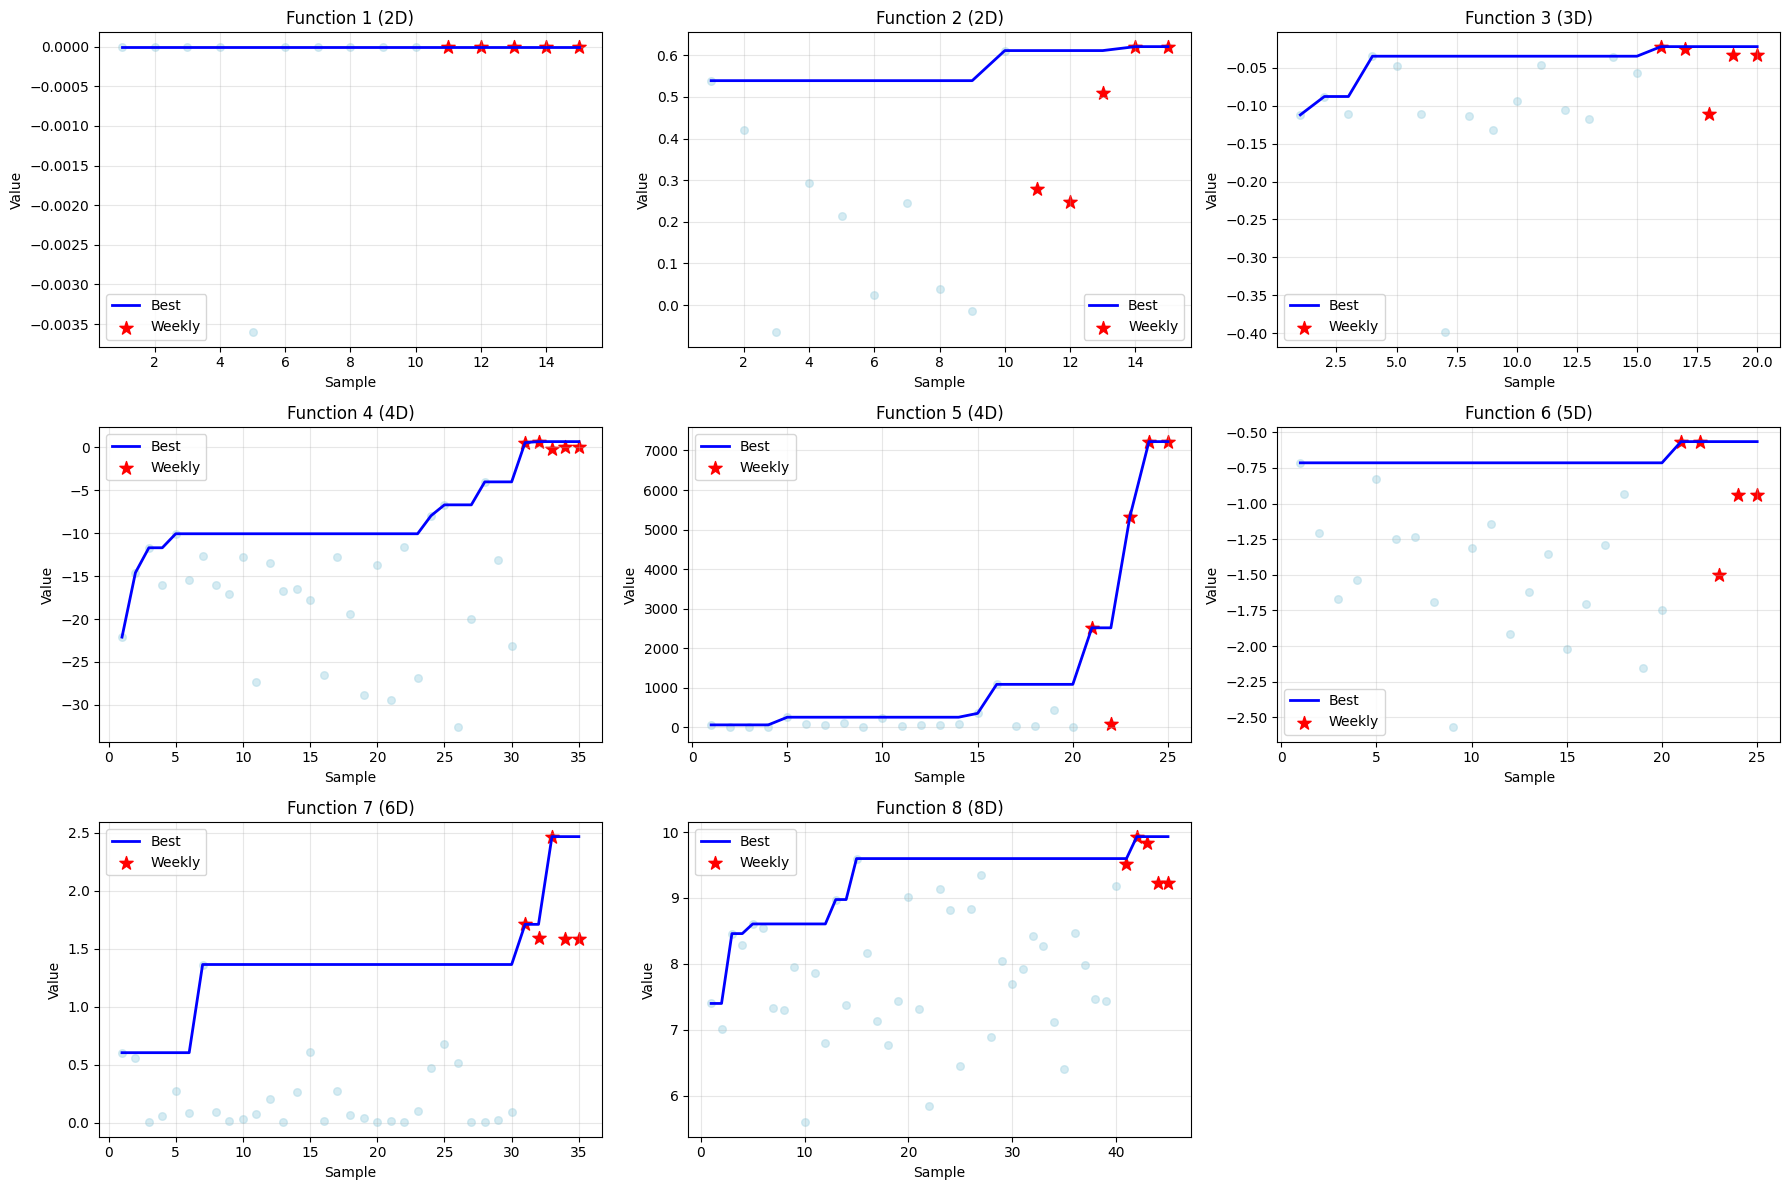

In [8]:
display_competition_summary(functions)
plot_progress(functions)

## 7. Manual single-function update (optional)

If you need to update one function by hand (e.g. corrected value):

In [ ]:
# update_function_with_result(functions, func_id=1, x=np.array([0.5, 0.5]), y=1.23, week=4, save=True)